In [2]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train_df = pd.read_csv('data/process/train_dataset_cleaned.csv')
test_df = pd.read_csv('data/process/test_dataset_cleaned.csv')

# Feature Engineering

In [4]:
# Load political-specific words from CSV files
def load_political_specific_words(top_n=500):
    """Load top N political-specific words from CSV"""
    pol_words = pd.read_csv('data/words/political_specific_words.csv')
    
    # If there's a frequency/count column, sort by it to get most important words
    # Otherwise, just take the first top_n words
    if 'count' in pol_words.columns or 'frequency' in pol_words.columns:
        count_col = 'count' if 'count' in pol_words.columns else 'frequency'
        pol_words = pol_words.sort_values(count_col, ascending=False)
    
    # Take top N words and convert to lowercase set
    all_pol_words = set(pol_words['word'].head(top_n).str.lower().tolist())
    
    return all_pol_words

political_specific_words = load_political_specific_words(top_n=500)

print(f"Political-specific words: {len(political_specific_words)} words (top 500)")

Political-specific words: 500 words (top 500)


In [5]:
# Build per-word importance weights from the full training corpus
from collections import Counter

def build_political_word_weights(text_series, political_words, transform="log1p"):
    """Build weights based on how many times each political word appears in ALL texts.

    transform:
      - "count"  -> raw corpus count
      - "log1p"  -> log(1+count) (still monotonic by count, but less explosive)
      - "freq"   -> count / total_political_word_count
    """
    counter = Counter()

    for text in text_series.fillna("").astype(str):
        words = text.lower().split()
        counter.update(w for w in words if w in political_words)

    counts = pd.Series(counter, dtype="int64").sort_values(ascending=False)

    if transform == "count":
        weights = counts.astype(float)
    elif transform == "log1p":
        weights = np.log1p(counts.astype(float))
    elif transform == "freq":
        total = float(counts.sum()) if float(counts.sum()) > 0 else 1.0
        weights = counts.astype(float) / total
    else:
        raise ValueError("transform must be one of: count, log1p, freq")

    return weights.to_dict(), counts

# Create weights using training corpus
political_word_weights, political_word_counts = build_political_word_weights(
    train_df["Processed_Text"],
    political_specific_words,
    transform="log1p",
)

print(f"Weighted lexicon size: {len(political_word_weights)}")
print("Top 20 political words by corpus count:")
display(political_word_counts.head(20))

# Save for reuse in other notebooks/scripts
pd.DataFrame({
    "word": political_word_counts.index,
    "count": political_word_counts.values,
    "weight": [political_word_weights[w] for w in political_word_counts.index],
}).to_csv("data/words/political_specific_word_weights.csv", index=False)
print("Saved: data/words/political_specific_word_weights.csv")

Weighted lexicon size: 474
Top 20 political words by corpus count:


তৃণমূল      69
amp         49
এবার        39
চাকরি       34
পিসি        33
বিজেপি      31
amanda      30
নেতা        30
তৃণমূলের    29
ভোট         29
কুচুটে      25
মমতা        24
করেছে       20
দুর্নীতি    19
সরকারি      19
সরকার       19
live        18
কোটি        18
পিসির       18
দাবি        18
dtype: int64

Saved: data/words/political_specific_word_weights.csv


In [6]:
def extract_text_features(text, political_specific_words, political_word_weights=None):
    """
    Extract political-specific word features from text.
    
    Features include:
    1. Political-specific word count
    2. Political-specific word ratio
    3. Political word presence importance (sum of per-word importance weights)
    """
    if pd.isna(text) or text == '':
        return {
            'political_specific_count': 0,
            'political_specific_ratio': 0.0,
            'political_presence_importance': 0.0,
            'political_unique_importance': 0.0
        }
    
    # Tokenize (kept consistent with earlier cells)
    words = text.lower().split()
    word_count = len(words)
    
    # Count political words
    political_words_in_text = [w for w in words if w in political_specific_words]
    political_specific_matches = len(political_words_in_text)
    political_specific_ratio = political_specific_matches / word_count if word_count > 0 else 0.0
    
    # Political word presence importance
    if political_word_weights is None:
        political_word_weights = {}
    political_presence_importance = float(sum(political_word_weights.get(w, 0.0) for w in political_words_in_text))
    political_unique_importance = float(sum(political_word_weights.get(w, 0.0) for w in set(political_words_in_text)))
    
    return {
        'political_specific_count': political_specific_matches,
        'political_specific_ratio': political_specific_ratio,
        'political_presence_importance': political_presence_importance,
        'political_unique_importance': political_unique_importance
    }

print("Feature extraction function defined!")

Feature extraction function defined!


In [7]:
# Extract features for training data
print("Extracting features from training data...")
train_features = train_df['Processed_Text'].apply(
    lambda x: extract_text_features(x, political_specific_words, political_word_weights)
 )

# Convert to DataFrame
train_features_df = pd.DataFrame(train_features.tolist())

# Combine with original dataframe
train_with_features = pd.concat([train_df, train_features_df], axis=1)

print(f"Training data shape: {train_with_features.shape}")

# Quick sanity check on new columns
display(train_with_features[['political_specific_count', 'political_presence_importance', 'political_unique_importance']].describe())

#train_with_features.to_csv('/kaggle/working/feature_engineering_txt.csv')
train_with_features.head(10)

Extracting features from training data...
Training data shape: (2860, 7)


,political_specific_count,political_presence_importance,political_unique_importance
count,2860.000000,2860.000000,2860.000000
mean,1.000699,2.262824,2.068805
std,2.193347,5.021538,4.518208
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,1.000000,1.945910,1.945910
max,18.000000,37.981597,32.084186


,Image_name,Label,Processed_Text,political_specific_count,political_specific_ratio,political_presence_importance,political_unique_importance
0,train0001.jpg,Political,হরেক রকম চোর দিয়া বানাইছো মেলা পিসি তোমার দরবা...,1,0.076923,3.526361,3.526361
1,train0002.jpg,NonPolitical,বর যাত্রী যাওয়ার টাইমে যখব গাড়িতে জায়গা কম পড়ে...,0,0.000000,0.000000,0.000000
2,train0003.jpg,NonPolitical,তুমিকেখা নাবলল বুকে অনেক ব্যখাহেয় ঠিক মত পানি ...,0,0.000000,0.000000,0.000000
3,train0004.jpg,NonPolitical,যখন ভল্লুক এসে পড়ে এবং আপন এবং আপনার রেস্টফরেন...,0,0.000000,0.000000,0.000000
4,train0005.jpg,NonPolitical,বন্ধুযখন তার গফকেকাজিন বলে পরিচয় দেয় সম্পর্কবদ...,0,0.000000,0.000000,0.000000
5,train0006.jpg,Political,নির্বাচনের দিন এগিয়ে আসছে সীমান্তের প্রতিটি ভা...,3,0.214286,6.579251,6.579251
6,train0007.jpg,NonPolitical,oeeije ceeuaar deejay ofeiraii আমীয় একটী পাখি ...,0,0.000000,0.000000,0.000000
7,train0008.jpg,Political,তদন্ত না করে পাকিস্তানকে দোষারোপ করাউচিং হয়ানি...,3,0.176471,5.828946,5.828946
8,train0009.jpg,NonPolitical,আমরহর্ট কেপ্রশ্ন করলামঃ নভালোবাস মানে কি? আকাই...,0,0.000000,0.000000,0.000000
9,train0010.jpg,Political,আমি আওয়ামীলীগ করি করোনাভাইরাস যখন জানতে পারে,0,0.000000,0.000000,0.000000


# Hybrid Model: Text Embeddings + Numerical Features

We'll combine:
- **Text embeddings** from mBERT (semantic understanding)
- **Numerical features** (political word counts/importance)

This captures both meaning and domain-specific signals.

In [8]:
# Install transformers if needed (uncomment if not installed)
# !pip install transformers torch

import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import StandardScaler

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

c:\bangla-political-memes-classification\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [9]:
# Load mBERT model and tokenizer
MODEL_NAME = 'bert-base-multilingual-cased'

print(f"Loading {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()  # Set to evaluation mode
print("Model loaded successfully!")

Loading bert-base-multilingual-cased...


Model loaded successfully!


In [10]:
def get_text_embeddings(texts, tokenizer, model, device, batch_size=32, max_length=128):
    """Extract [CLS] token embeddings from mBERT for a list of texts"""
    embeddings = []
    
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            
            # Tokenize
            encoded = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors='pt'
            ).to(device)
            
            # Get model output
            outputs = model(**encoded)
            
            # Use [CLS] token embedding (first token)
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls_embeddings)
            
            if (i // batch_size + 1) % 10 == 0:
                print(f"Processed {i+len(batch_texts)}/{len(texts)} texts...")
    
    return np.vstack(embeddings)

print("Embedding extraction function defined!")

Embedding extraction function defined!


In [11]:
# Extract text embeddings for training data
print("Extracting mBERT embeddings for training data...")
train_texts = train_with_features['Processed_Text'].fillna('').astype(str).tolist()

train_text_embeddings = get_text_embeddings(train_texts, tokenizer, model, device, batch_size=32)

print(f"Text embeddings shape: {train_text_embeddings.shape}")
print(f"Embedding dimension: {train_text_embeddings.shape[1]}")

Extracting mBERT embeddings for training data...


Processed 320/2860 texts...
Processed 640/2860 texts...
Processed 960/2860 texts...
Processed 1280/2860 texts...
Processed 1600/2860 texts...
Processed 1920/2860 texts...
Processed 2240/2860 texts...
Processed 2560/2860 texts...
Processed 2860/2860 texts...
Text embeddings shape: (2860, 768)
Embedding dimension: 768


In [12]:
# Combine text embeddings with numerical features
numerical_features = train_with_features[[
    'political_specific_count',
    'political_specific_ratio',
    'political_presence_importance',
    'political_unique_importance'
]].values

print(f"Numerical features shape: {numerical_features.shape}")

# Standardize numerical features
scaler = StandardScaler()
numerical_features_scaled = scaler.fit_transform(numerical_features)

# Combine embeddings + numerical features
X_combined = np.hstack([train_text_embeddings, numerical_features_scaled])

print(f"Combined feature shape: {X_combined.shape}")
print(f"  - Text embeddings: {train_text_embeddings.shape[1]} dims")
print(f"  - Numerical features: {numerical_features_scaled.shape[1]} dims")
print(f"  - Total: {X_combined.shape[1]} dims")

Numerical features shape: (2860, 4)
Combined feature shape: (2860, 772)
  - Text embeddings: 768 dims
  - Numerical features: 4 dims
  - Total: 772 dims


In [13]:
# Check available columns to identify the label column
print("Available columns in train_with_features:")
print(train_with_features.columns.tolist())
print(f"\nDataFrame shape: {train_with_features.shape}")
print("\nFirst few rows:")
display(train_with_features.head(3))

Available columns in train_with_features:
['Image_name', 'Label', 'Processed_Text', 'political_specific_count', 'political_specific_ratio', 'political_presence_importance', 'political_unique_importance']

DataFrame shape: (2860, 7)

First few rows:


,Image_name,Label,Processed_Text,political_specific_count,political_specific_ratio,political_presence_importance,political_unique_importance
0,train0001.jpg,Political,হরেক রকম চোর দিয়া বানাইছো মেলা পিসি তোমার দরবা...,1,0.076923,3.526361,3.526361
1,train0002.jpg,NonPolitical,বর যাত্রী যাওয়ার টাইমে যখব গাড়িতে জায়গা কম পড়ে...,0,0.000000,0.000000,0.000000
2,train0003.jpg,NonPolitical,তুমিকেখা নাবলল বুকে অনেক ব্যখাহেয় ঠিক মত পানি ...,0,0.000000,0.000000,0.000000


In [14]:
# Prepare labels and split data
# Auto-detect label column name (common variations: 'label', 'Label', 'is_political', etc.)
label_col_candidates = ['label', 'Label', 'is_political', 'political', 'target']
label_col = None

for col in label_col_candidates:
    if col in train_with_features.columns:
        label_col = col
        break

if label_col is None:
    raise ValueError(f"Could not find label column. Available columns: {train_with_features.columns.tolist()}")

print(f"Using label column: '{label_col}'")
y = train_with_features[label_col].values

# Split into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_combined, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Class distribution in training: {np.bincount(y_train)}")

Using label column: 'Label'
Training set: 2288 samples
Validation set: 572 samples


TypeError: Cannot cast array data from dtype('O') to dtype('int64') according to the rule 'safe'

In [ ]:
# Train Logistic Regression classifier
print("Training Logistic Regression on combined features...")

clf = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',  # Handle class imbalance
    C=1.0
)

clf.fit(X_train, y_train)

# Make predictions
y_train_pred = clf.predict(X_train)
y_val_pred = clf.predict(X_val)

# Calculate accuracies
train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)

print(f"\nTraining Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

Training Logistic Regression on combined features...

Training Accuracy: 0.9559
Validation Accuracy: 0.9266



=== VALIDATION SET EVALUATION ===

Classification Report:
               precision    recall  f1-score   support

Non-Political       0.95      0.95      0.95       401
    Political       0.88      0.88      0.88       171

     accuracy                           0.93       572
    macro avg       0.91      0.91      0.91       572
 weighted avg       0.93      0.93      0.93       572


Confusion Matrix:
[[380  21]
 [ 21 150]]


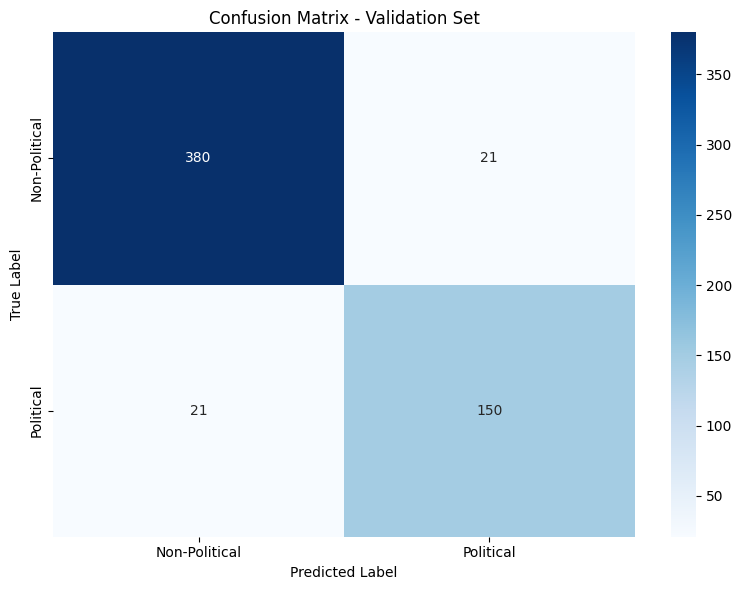

In [ ]:
# Detailed evaluation metrics
print("\n=== VALIDATION SET EVALUATION ===")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=['Non-Political', 'Political']))

# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)
print("\nConfusion Matrix:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Political', 'Political'],
            yticklabels=['Non-Political', 'Political'])
plt.title('Confusion Matrix - Validation Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [ ]:
# Save the trained model and scaler
import joblib

joblib.dump(clf, 'models/hybrid_text_political_classifier.pkl')
joblib.dump(scaler, 'models/numerical_features_scaler.pkl')

print("Model saved to: models/hybrid_text_political_classifier.pkl")
print("Scaler saved to: models/numerical_features_scaler.pkl")

# Test Data Prediction

Now let's process the test data and generate predictions.

In [ ]:
# Extract numerical features for test data
print("Extracting political word features for test data...")
test_features = test_df['Processed_Text'].apply(
    lambda x: extract_text_features(x, political_specific_words, political_word_weights)
)

test_features_df = pd.DataFrame(test_features.tolist())
test_with_features = pd.concat([test_df, test_features_df], axis=1)

print(f"Test data shape: {test_with_features.shape}")
test_with_features.head()

Extracting political word features for test data...
Test data shape: (330, 6)


,Image_name,Processed_Text,political_specific_count,political_specific_ratio,political_presence_importance,political_unique_importance
0,test0001.jpg,lose duck election comment ontheelection maid ...,1,0.125000,1.791759,1.791759
1,test0002.jpg,matlablige fun,0,0.000000,0.000000,0.000000
2,test0003.jpg,shlilisiiiiiieuiuriie,0,0.000000,0.000000,0.000000
3,test0004.jpg,one absolutely one random এনসিপি বাগছাস নেতা g...,2,0.153846,3.433987,3.433987
4,test0005.jpg,বন্ধু বিকাশের নতুন আপডেট দেখসস? অনেক নতুন ফিচা...,0,0.000000,0.000000,0.000000


In [ ]:
# Extract text embeddings for test data
print("Extracting mBERT embeddings for test data...")
test_texts = test_with_features['Processed_Text'].fillna('').astype(str).tolist()

test_text_embeddings = get_text_embeddings(test_texts, tokenizer, model, device, batch_size=32)

print(f"Test text embeddings shape: {test_text_embeddings.shape}")

Extracting mBERT embeddings for test data...
Processed 320/330 texts...
Test text embeddings shape: (330, 768)


In [ ]:
# Combine test features
test_numerical_features = test_with_features[[
    'political_specific_count',
    'political_specific_ratio',
    'political_presence_importance',
    'political_unique_importance'
]].values

# Scale numerical features using the fitted scaler
test_numerical_features_scaled = scaler.transform(test_numerical_features)

# Combine embeddings + numerical features
X_test_combined = np.hstack([test_text_embeddings, test_numerical_features_scaled])

print(f"Test combined feature shape: {X_test_combined.shape}")

Test combined feature shape: (330, 772)


In [ ]:
# Make predictions on test data
print("Making predictions on test data...")
test_predictions = clf.predict(X_test_combined)
test_probabilities = clf.predict_proba(X_test_combined)

# Add predictions to test dataframe
test_with_features['prediction'] = test_predictions
test_with_features['probability_political'] = test_probabilities[:, 1]

print(f"\nPrediction distribution:")
print(f"Non-Political: {(test_predictions == 0).sum()}")
print(f"Political: {(test_predictions == 1).sum()}")

test_with_features[['Image_name', 'prediction', 'probability_political', 
                     'political_specific_count', 'political_presence_importance']].head(10)

Making predictions on test data...

Prediction distribution:
Non-Political: 0
Political: 0


,Image_name,prediction,probability_political,political_specific_count,political_presence_importance
0,test0001.jpg,NonPolitical,0.063047,1,1.791759
1,test0002.jpg,NonPolitical,0.037189,0,0.000000
2,test0003.jpg,NonPolitical,0.002191,0,0.000000
3,test0004.jpg,Political,0.993753,2,3.433987
4,test0005.jpg,NonPolitical,0.265624,0,0.000000
5,test0006.jpg,Political,0.993694,1,1.098612
6,test0007.jpg,NonPolitical,0.007587,0,0.000000
7,test0008.jpg,NonPolitical,0.211480,0,0.000000
8,test0009.jpg,NonPolitical,0.327242,0,0.000000
9,test0010.jpg,NonPolitical,0.002284,0,0.000000


In [ ]:
# Create submission file
submission = test_with_features[['Image_name', 'prediction']].copy()
submission.columns = ['Image_name', 'Label']  # Rename to match expected format

# Save submission
submission_path = 'submissions/submission_hybrid_text_political.csv'
submission.to_csv(submission_path, index=False)

print(f"Submission saved to: {submission_path}")
print(f"Submission shape: {submission.shape}")
print("\nFirst 10 rows:")
print(submission.head(10))

# Also save detailed test results with all features for analysis
test_with_features.to_csv('data/predictions/test_with_political_features.csv', index=False)
print("\nDetailed test results saved to: data/predictions/test_with_political_features.csv")

NameError: name 'test_with_features' is not defined

# Summary

## Model Architecture
This hybrid model combines:
1. **mBERT text embeddings** (768 dimensions) - captures semantic meaning of Bangla text
2. **Political word features** (4 dimensions):
   - `political_specific_count`: number of political words
   - `political_specific_ratio`: ratio of political words to total words
   - `political_presence_importance`: sum of importance weights for all political words
   - `political_unique_importance`: sum of importance weights for unique political words

## Files Created
- `models/hybrid_text_political_classifier.pkl` - Trained logistic regression model
- `models/numerical_features_scaler.pkl` - Scaler for numerical features
- `data/words/political_specific_word_weights.csv` - Political word weights (corpus-based)
- `submissions/submission_hybrid_text_political.csv` - Submission file
- `data/predictions/test_with_political_features.csv` - Detailed test results with all features

## How It Works
The model handles different data types by:
1. Converting text → dense embeddings (mBERT)
2. Extracting numerical features from political word lexicon
3. Scaling numerical features to same range as embeddings
4. Concatenating both feature types
5. Training a single classifier on the combined features

This approach leverages both deep semantic understanding (from mBERT) and domain-specific knowledge (political word importance).